# Día 1: color, histogramas y segmentación para imágenes de mano

En este cuaderno vamos a trabajar con `strawberry.png` para aprender ideas básicas de visión por computador sin empezar directamente por OpenCV. La imagen tiene suficiente variedad de color y textura para practicar filtros, espacios de color, histogramas y segmentación dentro de un único ejemplo.

La idea es la siguiente:

- usar `numpy` para entender qué es realmente una imagen;
- usar `scipy` para filtrar, transformar y limpiar máscaras;
- entender qué es un espacio de color y por qué HSL/HSV son útiles cuando RGB no basta;
- usar histogramas 1D y 2D para leer una imagen antes de umbralizarla;
- usar `scikit-learn` para segmentación sencilla con `KMeans` sobre rasgos de color;
- usar OpenCV cuando de verdad aporta algo importante, como conversiones de color o geometría.

Dicho de otra forma: primero entendemos las operaciones; luego usamos OpenCV como caja de herramientas especializada, no como magia negra.

## Instalación

```bash
pip install --upgrade numpy scipy scikit-learn matplotlib pillow pandas opencv-python
```

## Importaciones

In [1]:
from pathlib import Path
import colorsys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
from sklearn.cluster import KMeans

## Cargar la imagen

Vamos a trabajar con una imagen que ya está en el repositorio.

In [2]:
ruta_imagen = Path("strawberry.png")
imagen_original = Image.open(ruta_imagen).convert("RGB")

Lo primero que haremos será reducir resolución. La imagen original es bastante grande y, para una notebook docente, no aporta demasiado trabajar con tantos píxeles desde el principio.

Aquí reducimos ancho y alto al `20%` de su tamaño original.

In [173]:
factor_reduccion = 0.20
nuevo_tamano = (
    int(imagen_original.width * factor_reduccion),
    int(imagen_original.height * factor_reduccion),
)

In [174]:
imagen = np.array(imagen_original.resize(nuevo_tamano, Image.LANCZOS))

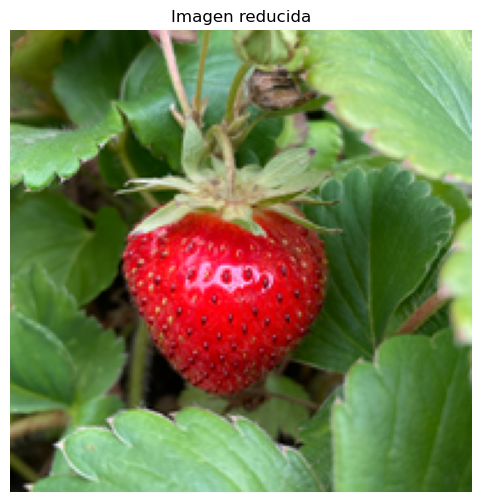

In [175]:
plt.figure(figsize=(6, 6))
plt.imshow(imagen)
plt.title("Imagen reducida")
plt.axis("off")
plt.show()

## Qué es una imagen para Python

Para una librería numérica, una imagen no es “una fresa”. Es un array.

En una imagen RGB normal:

- el primer eje es la fila;
- el segundo eje es la columna;
- el tercer eje contiene los tres canales de color.

In [176]:
imagen.shape

(200, 200, 3)

In [177]:
imagen.dtype

dtype('uint8')

In [178]:
imagen.size

120000

In [179]:
pd.DataFrame(
    [
        {
            "alto": imagen.shape[0],
            "ancho": imagen.shape[1],
            "canales": imagen.shape[2],
            "dtype": str(imagen.dtype),
            "num_valores": imagen.size,
        }
    ]
)

,alto,ancho,canales,dtype,num_valores
0,200,200,3,uint8,120000


## Leer píxeles concretos

Cada píxel contiene tres números: rojo, verde y azul.

In [180]:
imagen[0, 0]

array([ 98, 103,  53], dtype=uint8)

In [181]:
imagen[100, 80]

array([254,  42,  88], dtype=uint8)

Esto es útil porque nos recuerda que cualquier algoritmo de visión trabaja, en el fondo, con tablas de números.

## Ver los canales por separado

Separar canales ayuda a entender qué información aporta cada uno.

In [182]:
canal_rojo = imagen[:, :, 0]
canal_verde = imagen[:, :, 1]
canal_azul = imagen[:, :, 2]

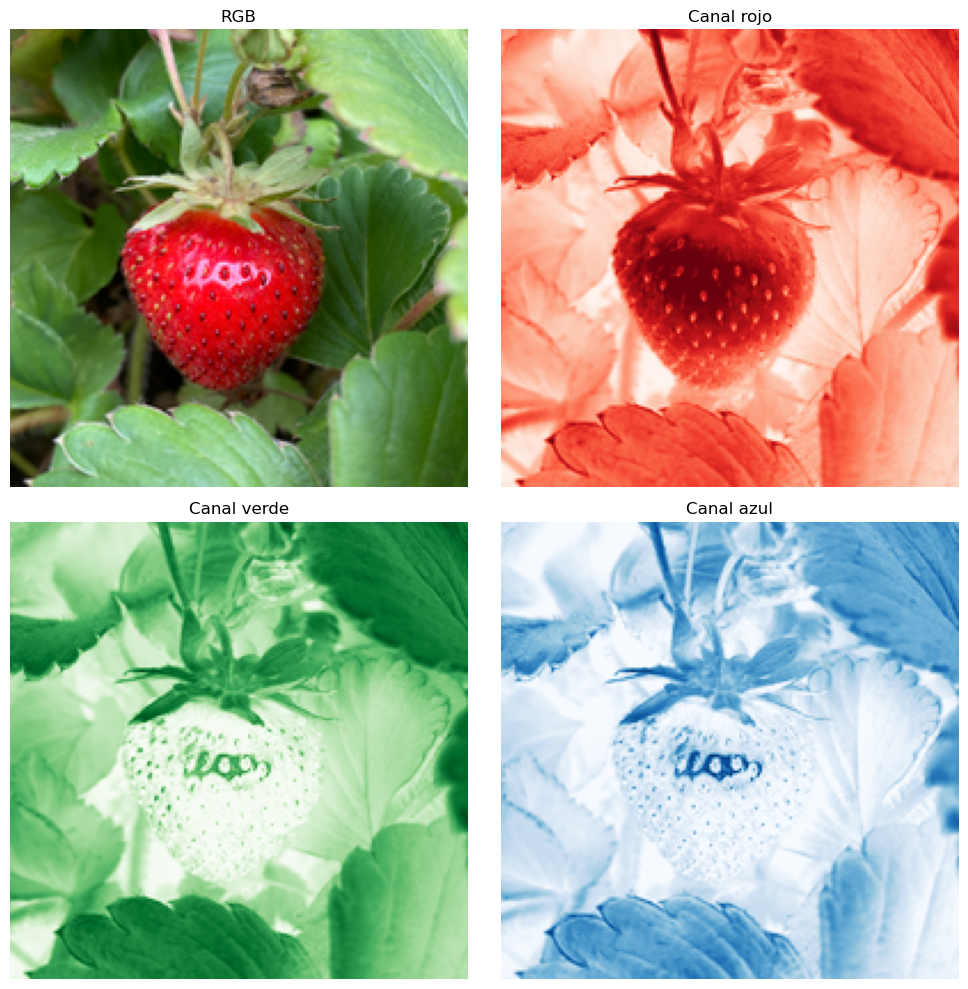

In [183]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(imagen)
axes[0, 0].set_title("RGB")
axes[0, 0].axis("off")

axes[0, 1].imshow(canal_rojo, cmap="Reds")
axes[0, 1].set_title("Canal rojo")
axes[0, 1].axis("off")

axes[1, 0].imshow(canal_verde, cmap="Greens")
axes[1, 0].set_title("Canal verde")
axes[1, 0].axis("off")

axes[1, 1].imshow(canal_azul, cmap="Blues")
axes[1, 1].set_title("Canal azul")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

## Escala de grises con numpy

Muchas técnicas clásicas empiezan convirtiendo la imagen a una sola intensidad.

Una forma estándar es hacer una combinación ponderada de los canales:

$$
I = 0.299 R + 0.587 G + 0.114 B
$$

Estos pesos no salen de la nada: reflejan que el ojo humano percibe el verde como más luminoso que el azul.

In [184]:
imagen_float = imagen.astype(np.float32)

In [185]:
imagen_gris = (
    0.299 * imagen_float[:, :, 0]
    + 0.587 * imagen_float[:, :, 1]
    + 0.114 * imagen_float[:, :, 2]
)

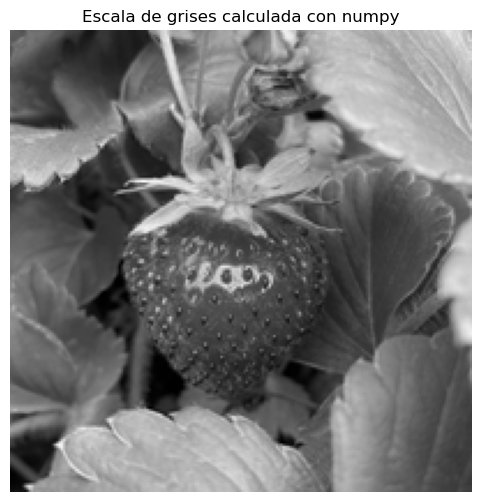

In [186]:
plt.figure(figsize=(6, 6))
plt.imshow(imagen_gris, cmap="gray")
plt.title("Escala de grises calculada con numpy")
plt.axis("off")
plt.show()

## Filtrado con scipy: promedio local

En la notebook antigua aparecía `filter2D` de OpenCV. La idea matemática es más general: aplicar una convolución con un kernel.

Aquí lo hacemos con `scipy.ndimage.convolve`.

Un kernel promedio de `5 x 5` asigna el mismo peso a los 25 píxeles vecinos.

In [187]:
kernel_promedio = np.ones((5, 5), dtype=np.float32) / 25
kernel_promedio

array([[0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04]], dtype=float32)

In [188]:
imagen_gris_promedio = ndimage.convolve(imagen_gris, kernel_promedio, mode="reflect")

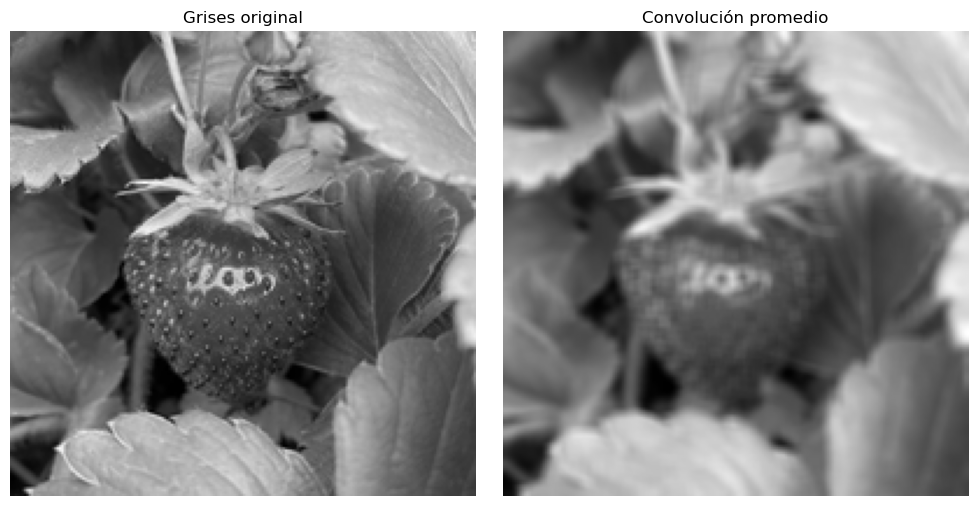

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(imagen_gris, cmap="gray")
axes[0].set_title("Grises original")
axes[0].axis("off")

axes[1].imshow(imagen_gris_promedio, cmap="gray")
axes[1].set_title("Convolución promedio")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Filtrado gaussiano con scipy

El filtro promedio suaviza, pero suele emborronar demasiado los bordes. Una alternativa clásica es el filtro gaussiano.

`scipy.ndimage.gaussian_filter` recibe como parámetro principal `sigma`, que controla cuánto se reparte el peso alrededor del píxel central.

- `sigma` pequeño: poco suavizado;
- `sigma` grande: mucho suavizado.

In [190]:
imagen_gris_gauss_2 = ndimage.gaussian_filter(imagen_gris, sigma=2)
imagen_gris_gauss_6 = ndimage.gaussian_filter(imagen_gris, sigma=6)

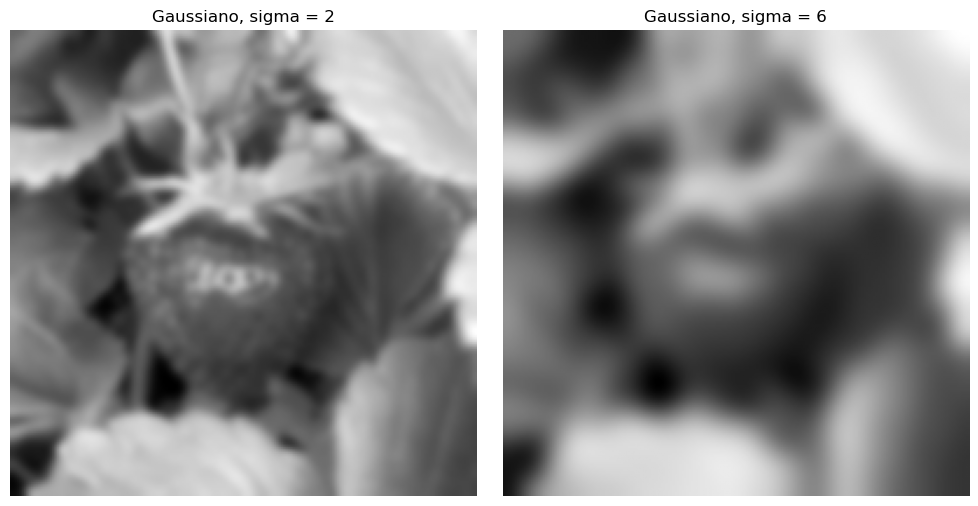

In [191]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(imagen_gris_gauss_2, cmap="gray")
axes[0].set_title("Gaussiano, sigma = 2")
axes[0].axis("off")

axes[1].imshow(imagen_gris_gauss_6, cmap="gray")
axes[1].set_title("Gaussiano, sigma = 6")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Bordes con gradientes de scipy

Otra operación clásica es calcular derivadas espaciales. `scipy.ndimage.sobel` aproxima el gradiente horizontal o vertical.

In [192]:
sobel_x = ndimage.sobel(imagen_gris, axis=1)
sobel_y = ndimage.sobel(imagen_gris, axis=0)

In [193]:
magnitud_gradiente = np.hypot(sobel_x, sobel_y)

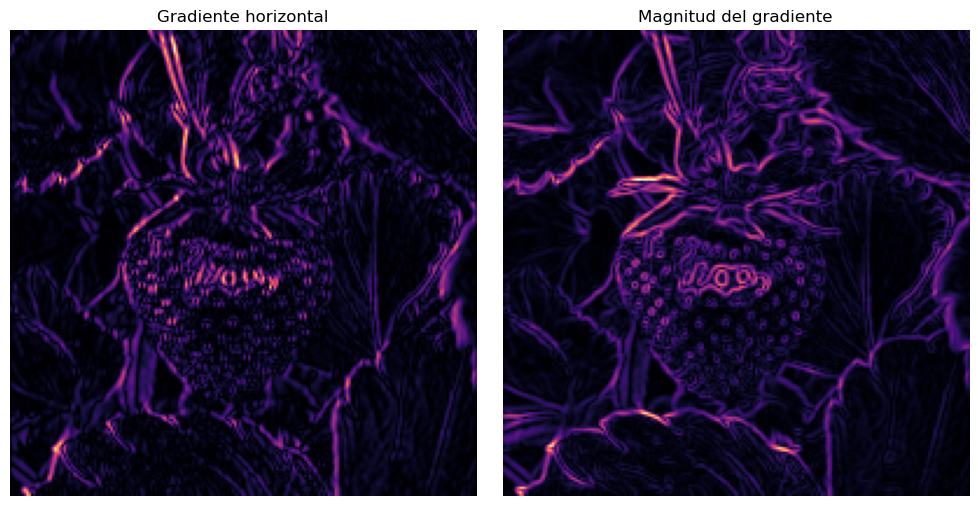

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(np.abs(sobel_x), cmap="magma")
axes[0].set_title("Gradiente horizontal")
axes[0].axis("off")

axes[1].imshow(magnitud_gradiente, cmap="magma")
axes[1].set_title("Magnitud del gradiente")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Mirar color sobre la fresa

Hasta ahora hemos trabajado ideas generales con intensidad, filtros y bordes. Ahora seguimos con la misma `strawberry.png`, pero centrándonos en algo que sí usarán luego en el curso: pensar en color, histogramas y segmentación.

La pregunta ahora no es geométrica, sino esta:

- cómo separar la fresa del resto de la escena;
- qué variables son más útiles para hacerlo;
- cuándo conviene usar umbrales y cuándo clustering.

In [195]:
imagen_color = imagen.copy()
imagen_color_float = imagen_color.astype(np.float32) / 255.0
imagen_color.shape

(200, 200, 3)

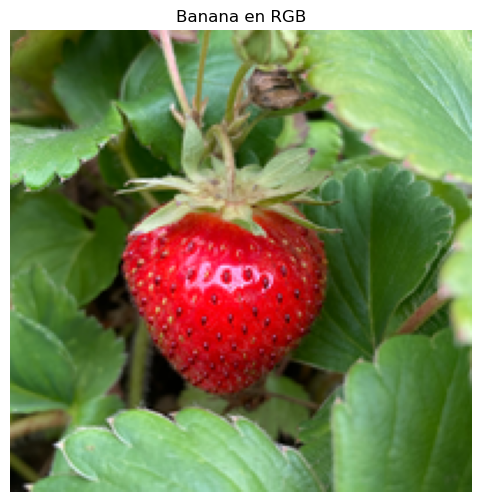

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(imagen_color)
plt.title("Fresa en RGB")
plt.axis("off")
plt.show()

## Qué es un espacio de color

RGB es solo una forma de representar color, pero no siempre es la más cómoda para segmentar.

Cuando queremos separar regiones por “tono”, “pureza del color” o “claridad”, suele ser mejor cambiar de espacio de color.

Las dos ideas más útiles aquí son:

- `HSL`: tono, saturación y luminosidad;
- `HSV`: tono, saturación y valor.

No son iguales:

- en HSL, la componente importante es la **luminosidad**;
- en HSV, la componente importante es el **valor** o brillo máximo del píxel.

Python estándar usa el nombre `HLS`, pero conceptualmente es la misma idea que HSL: solo cambia el orden de las componentes.

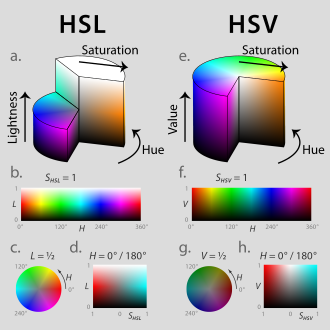

## Convertir la imagen a HSL y HSV

In [222]:
pixeles_hls = np.array(
    [colorsys.rgb_to_hls(*pixel) for pixel in imagen_color_float.reshape(-1, 3)],
    dtype=np.float32,
)
hls_fresa = pixeles_hls.reshape(*imagen_color.shape[:2], 3)

hue_hsl = hls_fresa[:, :, 0]
lightness_hsl = hls_fresa[:, :, 1]
saturation_hsl = hls_fresa[:, :, 2]

hsv_fresa = cv2.cvtColor(imagen_color, cv2.COLOR_RGB2HSV)
hue_hsv = hsv_fresa[:, :, 0] / 179.0
saturation_hsv = hsv_fresa[:, :, 1] / 255.0
value_hsv = hsv_fresa[:, :, 2] / 255.0

gris_fresa = cv2.cvtColor(imagen_color, cv2.COLOR_RGB2GRAY)

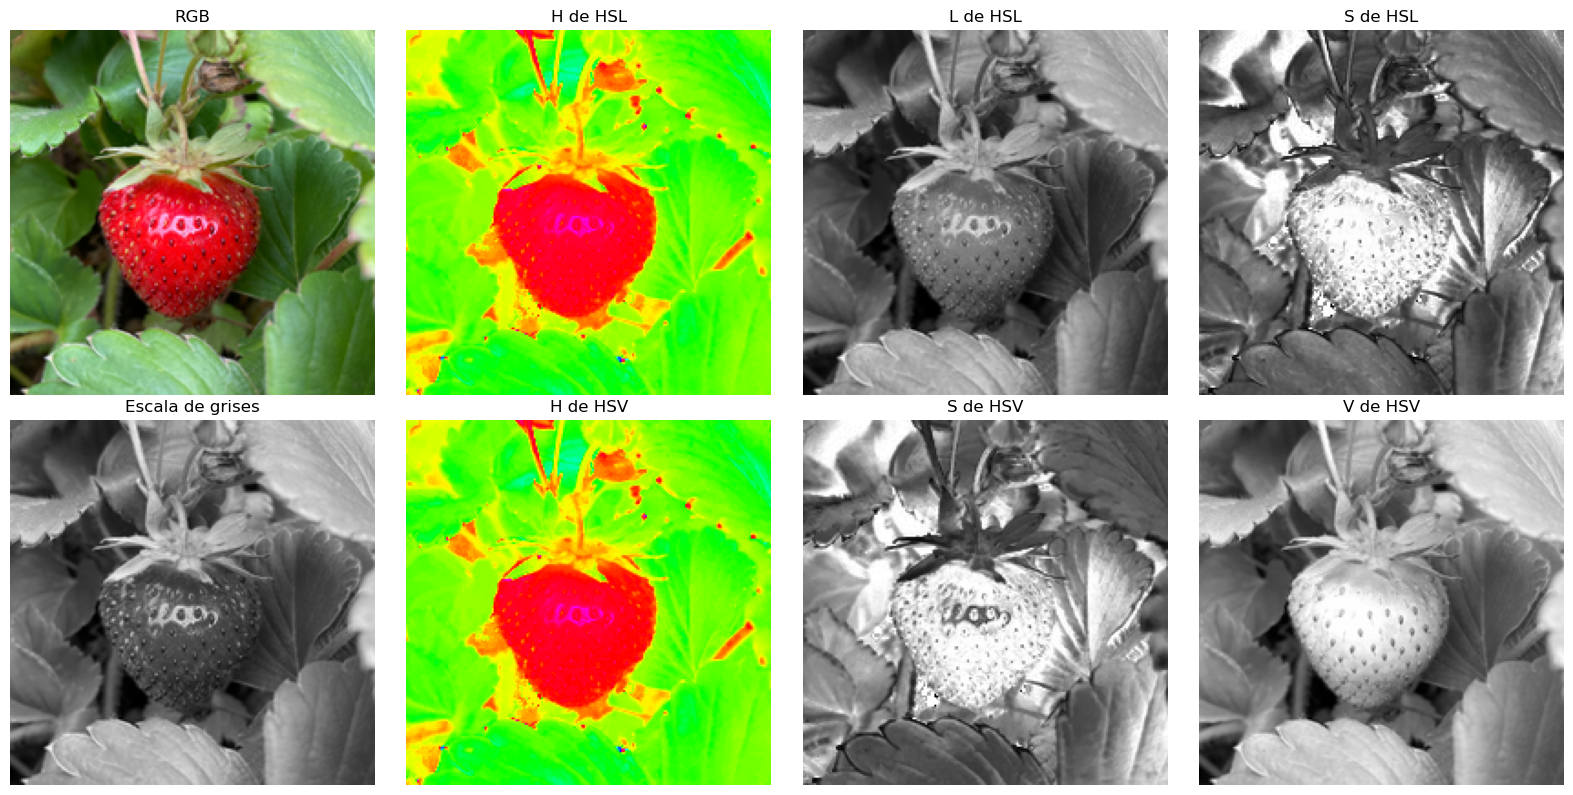

In [223]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes[0, 0].imshow(imagen_color)
axes[0, 0].set_title("RGB")
axes[0, 0].axis("off")

axes[0, 1].imshow(hue_hsl, cmap="hsv")
axes[0, 1].set_title("H de HSL")
axes[0, 1].axis("off")

axes[0, 2].imshow(lightness_hsl, cmap="gray")
axes[0, 2].set_title("L de HSL")
axes[0, 2].axis("off")

axes[0, 3].imshow(saturation_hsl, cmap="gray")
axes[0, 3].set_title("S de HSL")
axes[0, 3].axis("off")

axes[1, 0].imshow(gris_fresa, cmap="gray")
axes[1, 0].set_title("Escala de grises")
axes[1, 0].axis("off")

axes[1, 1].imshow(hue_hsv, cmap="hsv")
axes[1, 1].set_title("H de HSV")
axes[1, 1].axis("off")

axes[1, 2].imshow(saturation_hsv, cmap="gray")
axes[1, 2].set_title("S de HSV")
axes[1, 2].axis("off")

axes[1, 3].imshow(value_hsv, cmap="gray")
axes[1, 3].set_title("V de HSV")
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

## Espacio YCbCr

Es otro espacio de color que separa la información de luminancia (Y) de la información de crominancia (Cb y Cr). Es útil para tareas como compresión o segmentación basada en color, ya que permite trabajar con la información de color sin afectar la luminosidad.

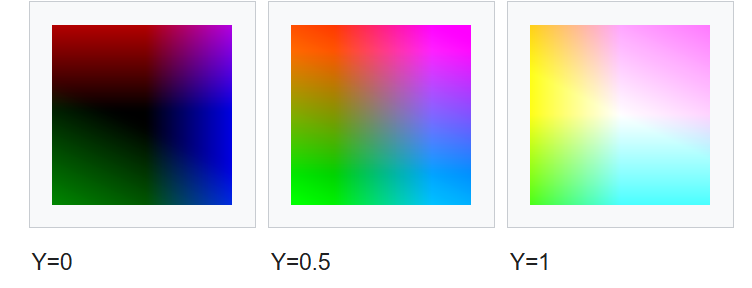

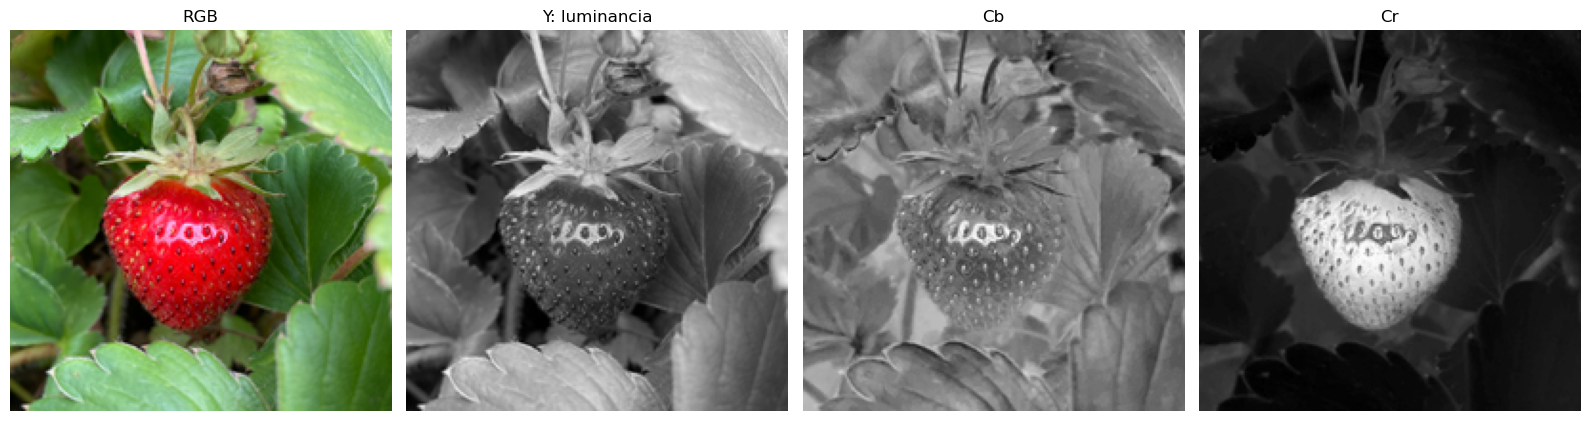

In [224]:
ycbcr_fresa = cv2.cvtColor(imagen_color, cv2.COLOR_RGB2YCrCb)

luminancia_y = ycbcr_fresa[:, :, 0]
croma_cr = ycbcr_fresa[:, :, 1]
croma_cb = ycbcr_fresa[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

axes[0].imshow(imagen_color)
axes[0].set_title("RGB")
axes[0].axis("off")

axes[1].imshow(luminancia_y, cmap="gray")
axes[1].set_title("Y: luminancia")
axes[1].axis("off")

axes[2].imshow(croma_cb, cmap="gray")
axes[2].set_title("Cb")
axes[2].axis("off")

axes[3].imshow(croma_cr, cmap="gray")
axes[3].set_title("Cr")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Histogramas 1D: leer una imagen antes de segmentar

Antes de poner umbrales, conviene mirar histogramas.

Un histograma responde a una pregunta muy concreta: cuántos píxeles caen en cada rango de valores.

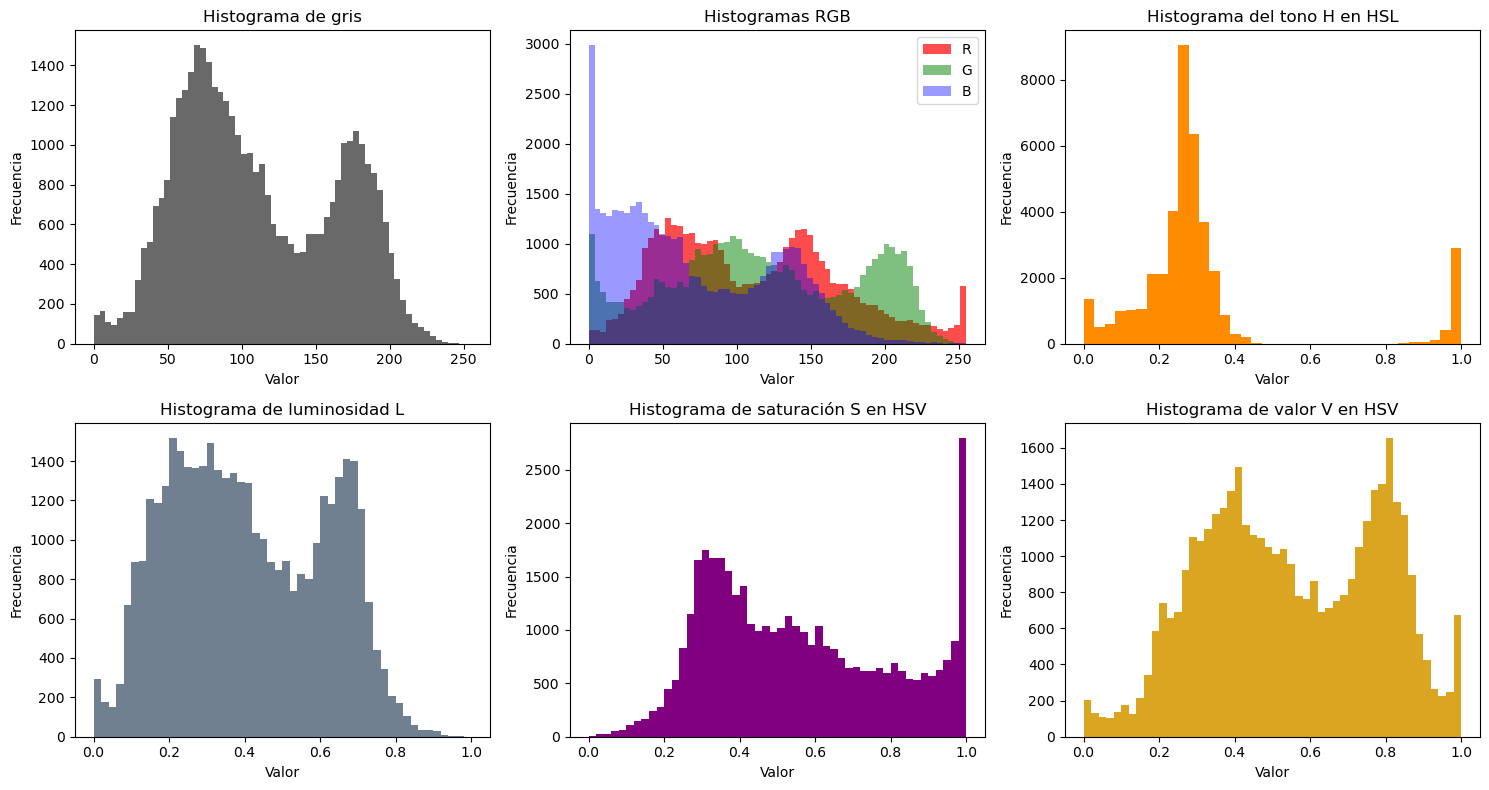

In [225]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].hist(gris_fresa.ravel(), bins=64, range=(0, 255), color="dimgray")
axes[0, 0].set_title("Histograma de gris")

axes[0, 1].hist(imagen_color[:, :, 0].ravel(), bins=64, range=(0, 255), color="red", alpha=0.7, label="R")
axes[0, 1].hist(imagen_color[:, :, 1].ravel(), bins=64, range=(0, 255), color="green", alpha=0.5, label="G")
axes[0, 1].hist(imagen_color[:, :, 2].ravel(), bins=64, range=(0, 255), color="blue", alpha=0.4, label="B")
axes[0, 1].set_title("Histogramas RGB")
axes[0, 1].legend()

axes[0, 2].hist(hue_hsl.ravel(), bins=36, range=(0, 1), color="darkorange")
axes[0, 2].set_title("Histograma del tono H en HSL")

axes[1, 0].hist(lightness_hsl.ravel(), bins=50, range=(0, 1), color="slategray")
axes[1, 0].set_title("Histograma de luminosidad L")

axes[1, 1].hist(saturation_hsv.ravel(), bins=50, range=(0, 1), color="purple")
axes[1, 1].set_title("Histograma de saturación S en HSV")

axes[1, 2].hist(value_hsv.ravel(), bins=50, range=(0, 1), color="goldenrod")
axes[1, 2].set_title("Histograma de valor V en HSV")

for ax in axes.ravel():
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Histogramas 2D: ver relaciones entre canales

Los histogramas 1D ayudan, pero a veces dos regiones se separan mejor combinando dos variables a la vez.

Eso es exactamente lo que hacen los histogramas 2D.

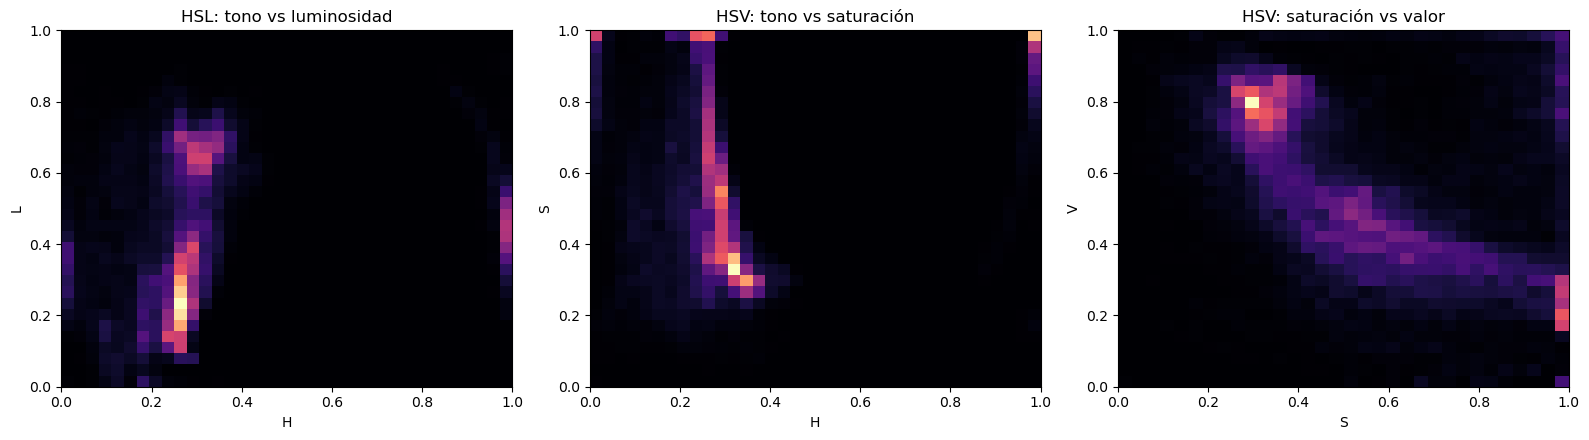

In [201]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist2d(hue_hsl.ravel(), lightness_hsl.ravel(), bins=[36, 32], range=[[0, 1], [0, 1]], cmap="magma")
axes[0].set_title("HSL: tono vs luminosidad")
axes[0].set_xlabel("H")
axes[0].set_ylabel("L")

axes[1].hist2d(hue_hsv.ravel(), saturation_hsv.ravel(), bins=[36, 32], range=[[0, 1], [0, 1]], cmap="magma")
axes[1].set_title("HSV: tono vs saturación")
axes[1].set_xlabel("H")
axes[1].set_ylabel("S")

axes[2].hist2d(saturation_hsv.ravel(), value_hsv.ravel(), bins=[32, 32], range=[[0, 1], [0, 1]], cmap="magma")
axes[2].set_title("HSV: saturación vs valor")
axes[2].set_xlabel("S")
axes[2].set_ylabel("V")

plt.tight_layout()
plt.show()

La lectura útil aquí es esta:

- el rojo intenso de la fresa cae cerca de los extremos del tono en HSV;
- las hojas verdes y el fondo ocupan zonas distintas en tono y saturación;
- separar la fresa del resto es más fácil cuando combinamos tono, saturación y valor que cuando usamos solo gris.

## Umbralizar con variables que sí tienen sentido

En lugar de poner umbrales directamente en RGB, vamos a usar variables con interpretación más clara para obtener una máscara inicial de la fresa.

In [217]:
fresa_seed = (
    ((hue_hsv < 0.05) | (hue_hsv > 0.95))
    & (saturation_hsv > 0.35)
    & (value_hsv > 0.20)
)
resto_seed = ~fresa_seed

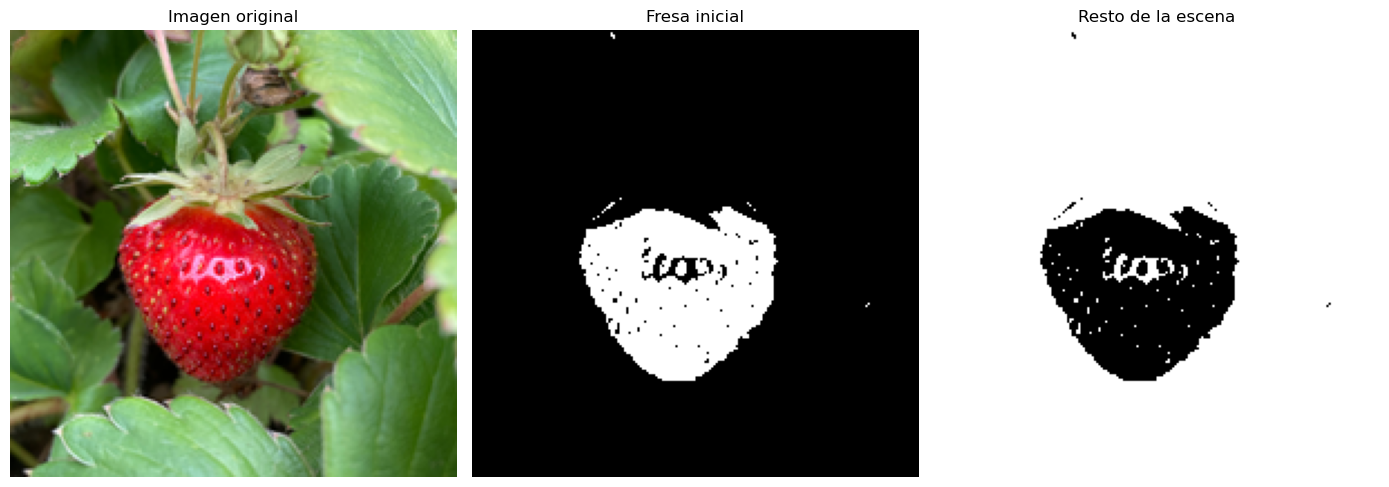

In [218]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(imagen_color)
axes[0].set_title("Imagen original")
axes[0].axis("off")

axes[1].imshow(fresa_seed, cmap="gray")
axes[1].set_title("Fresa inicial")
axes[1].axis("off")

axes[2].imshow(resto_seed, cmap="gray")
axes[2].set_title("Resto de la escena")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Limpiar máscaras con morfología

Las máscaras iniciales suelen tener ruido. Con `scipy.ndimage` podemos limpiarlas sin necesidad de recurrir a OpenCV.

En esta parte merece la pena ver cada paso por separado:

- la **erosión** elimina píxeles aislados y estrecha la máscara;
- la **dilatación** recupera volumen y reconecta regiones cercanas;
- después rellenamos huecos interiores y nos quedamos con la componente principal.

In [219]:
estructura_erosion = np.ones((5, 5), dtype=bool)
estructura_dilatacion = np.ones((9, 9), dtype=bool)

fresa_erosionada = ndimage.binary_erosion(fresa_seed, structure=estructura_erosion)
fresa_dilatada = ndimage.binary_dilation(fresa_erosionada, structure=estructura_dilatacion)
fresa_mask = ndimage.binary_fill_holes(fresa_dilatada)

In [220]:
labels_fresa, n_fresas = ndimage.label(fresa_mask)
if n_fresas == 0:
    raise ValueError("No se ha detectado ninguna componente en la máscara de la fresa.")

areas_fresa = ndimage.sum(fresa_mask.astype(np.uint8), labels_fresa, index=np.arange(1, n_fresas + 1))
etiqueta_fresa = np.argmax(areas_fresa) + 1
fresa_principal = labels_fresa == etiqueta_fresa

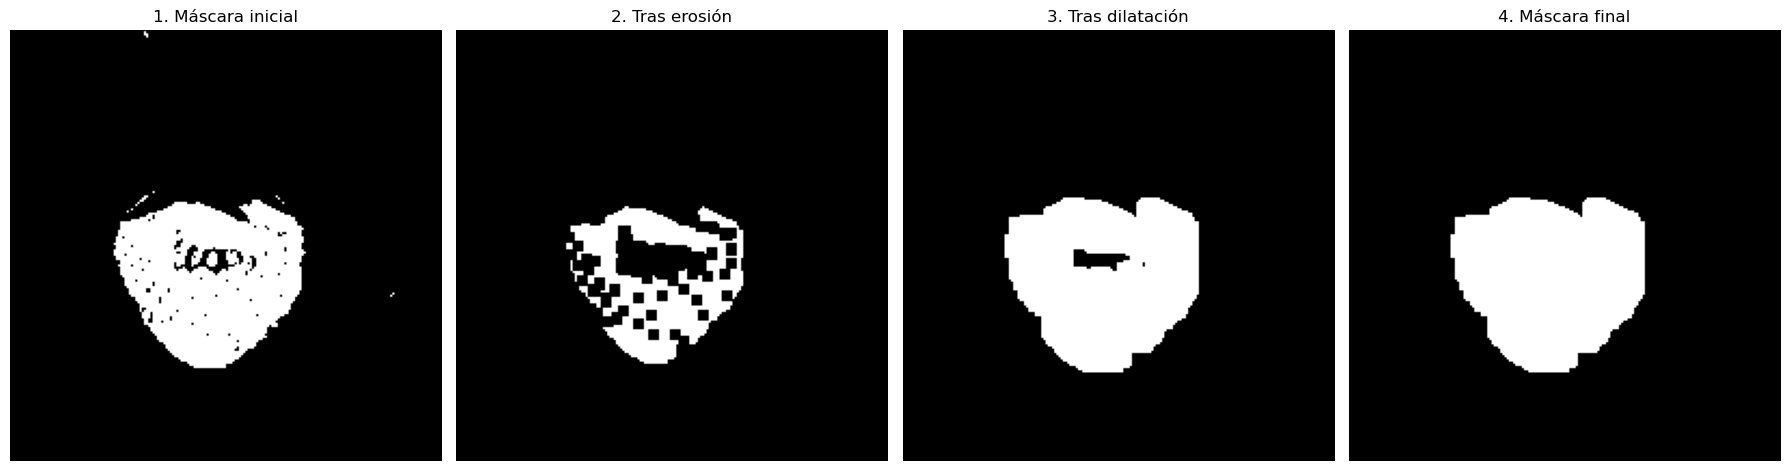

In [221]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(fresa_seed, cmap="gray")
axes[0].set_title("1. Máscara inicial")
axes[0].axis("off")

axes[1].imshow(fresa_erosionada, cmap="gray")
axes[1].set_title("2. Tras erosión")
axes[1].axis("off")

axes[2].imshow(fresa_dilatada, cmap="gray")
axes[2].set_title("3. Tras dilatación")
axes[2].axis("off")

axes[3].imshow(fresa_principal, cmap="gray")
axes[3].set_title("4. Máscara final")
axes[3].axis("off")

plt.tight_layout()
plt.show()

## Segmentar una zona brillante de la fresa

No toda la fresa refleja la luz igual. Las zonas con brillo especular suelen verse más claras y menos saturadas que el rojo dominante. Eso nos permite practicar una segunda segmentación dentro del mismo objeto.

In [234]:
zona_brillante_seed = (
    fresa_principal
    & (value_hsv > 0.68)
    & (saturation_hsv < 0.72)
)
zona_brillante = ndimage.binary_opening(zona_brillante_seed, structure=np.ones((3, 3), dtype=bool))
zona_brillante = ndimage.binary_closing(zona_brillante, structure=np.ones((7, 7), dtype=bool))

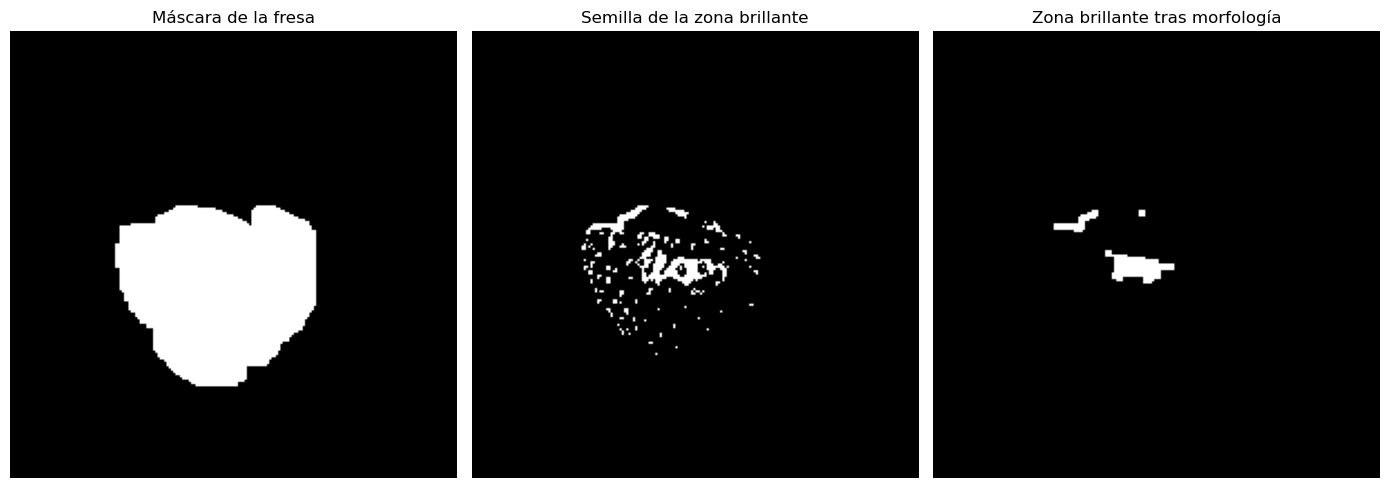

In [235]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(fresa_principal, cmap="gray")
axes[0].set_title("Máscara de la fresa")
axes[0].axis("off")

axes[1].imshow(zona_brillante_seed, cmap="gray")
axes[1].set_title("Semilla de la zona brillante")
axes[1].axis("off")

axes[2].imshow(zona_brillante, cmap="gray")
axes[2].set_title("Zona brillante tras morfología")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Usar `KMeans` sobre rasgos de color

Otra alternativa útil es no fijar el corte exacto a mano, sino agrupar píxeles por sus rasgos de color.

Aquí usamos solo dos rasgos muy interpretables dentro de la fresa:

- `S` en HSV;
- `V` en HSV.

In [228]:
rasgos_sv = np.column_stack(
    [
        saturation_hsv[fresa_principal],
        value_hsv[fresa_principal],
    ]
)

kmeans_sv = KMeans(n_clusters=3, n_init="auto", random_state=0)
etiquetas_sv = kmeans_sv.fit_predict(rasgos_sv)
centros_sv = kmeans_sv.cluster_centers_
cluster_brillo_fresa = np.argmax(centros_sv[:, 1] - 0.4 * centros_sv[:, 0])

mascara_kmeans_brillo = np.zeros_like(fresa_principal, dtype=bool)
mascara_kmeans_brillo[fresa_principal] = etiquetas_sv == cluster_brillo_fresa
mascara_kmeans_brillo = ndimage.binary_opening(mascara_kmeans_brillo, structure=np.ones((3, 3), dtype=bool))
mascara_kmeans_brillo = ndimage.binary_closing(mascara_kmeans_brillo, structure=np.ones((7, 11), dtype=bool))

In [210]:
pd.DataFrame(centros_sv, columns=["saturacion_hsv", "valor_hsv"]).round(3)

,saturacion_hsv,valor_hsv
0,0.924,0.837
1,0.802,0.446
2,0.508,0.841


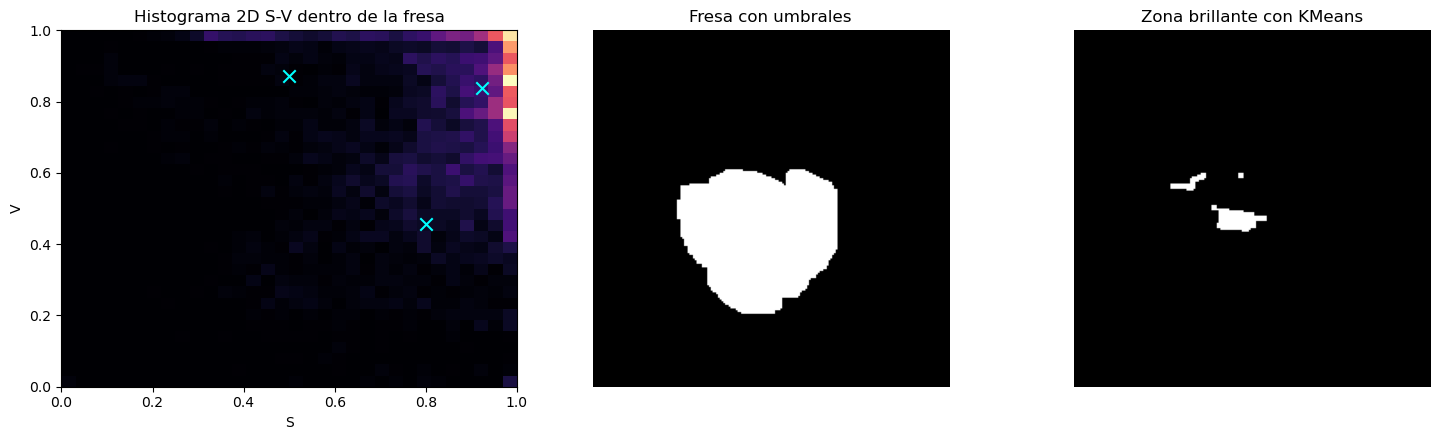

In [229]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist2d(rasgos_sv[:, 0], rasgos_sv[:, 1], bins=[32, 32], range=[[0, 1], [0, 1]], cmap="magma")
axes[0].scatter(centros_sv[:, 0], centros_sv[:, 1], c="cyan", s=80, marker="x")
axes[0].set_title("Histograma 2D S-V dentro de la fresa")
axes[0].set_xlabel("S")
axes[0].set_ylabel("V")

axes[1].imshow(fresa_principal, cmap="gray")
axes[1].set_title("Fresa con umbrales")
axes[1].axis("off")

axes[2].imshow(mascara_kmeans_brillo, cmap="gray")
axes[2].set_title("Zona brillante con KMeans")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## OpenCV donde realmente ayuda: contornos y caja rotada

Para limpiar o umbralizar no lo hemos necesitado. Pero para geometría, OpenCV sigue siendo muy cómodo sobre la máscara final de la fresa.

In [212]:
def order_points_clockwise(points):
    sums = points.sum(axis=1)
    diffs = np.diff(points, axis=1).ravel()
    top_left = points[np.argmin(sums)]
    bottom_right = points[np.argmax(sums)]
    top_right = points[np.argmin(diffs)]
    bottom_left = points[np.argmax(diffs)]
    return np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)

In [230]:
contornos_fresa, _ = cv2.findContours((fresa_principal.astype(np.uint8) * 255), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fresa = max(contornos_fresa, key=cv2.contourArea)
rect_fresa = cv2.minAreaRect(contorno_fresa)
caja_fresa = order_points_clockwise(cv2.boxPoints(rect_fresa).astype(np.int32))

In [236]:
ys_brillo, xs_brillo = np.where(zona_brillante)
if xs_brillo.size == 0:
    ys_brillo, xs_brillo = np.where(mascara_kmeans_brillo)

x_min_brillo, x_max_brillo = xs_brillo.min(), xs_brillo.max()
y_min_brillo, y_max_brillo = ys_brillo.min(), ys_brillo.max()

In [237]:
visual = imagen_color.copy()
cv2.drawContours(visual, [caja_fresa.astype(np.int32)], -1, (255, 0, 0), 3)
cv2.rectangle(visual, (x_min_brillo, y_min_brillo), (x_max_brillo, y_max_brillo), (0, 255, 255), 3)

array([[[ 98, 103,  53],
        [ 93, 101,  50],
        [ 91, 100,  48],
        ...,
        [179, 218, 154],
        [156, 205, 121],
        [142, 196, 118]],

       [[ 94, 103,  51],
        [ 91, 101,  50],
        [ 90, 101,  49],
        ...,
        [174, 216, 152],
        [176, 218, 141],
        [156, 207, 121]],

       [[ 92, 101,  48],
        [ 88, 100,  46],
        [ 87, 100,  46],
        ...,
        [170, 216, 153],
        [195, 227, 169],
        [164, 209, 129]],

       ...,

       [[  9,  10,   4],
        [ 10,  10,   4],
        [ 11,  11,   6],
        ...,
        [ 44,  81,  13],
        [ 43,  80,  15],
        [ 41,  78,  16]],

       [[ 12,  11,   5],
        [ 13,  12,   7],
        [ 13,  13,   7],
        ...,
        [ 47,  83,  18],
        [ 46,  82,  18],
        [ 44,  81,  18]],

       [[ 19,  17,  11],
        [ 17,  16,  12],
        [ 24,  24,  18],
        ...,
        [ 44,  81,  14],
        [ 43,  79,  15],
        [ 43,  79,  17]]

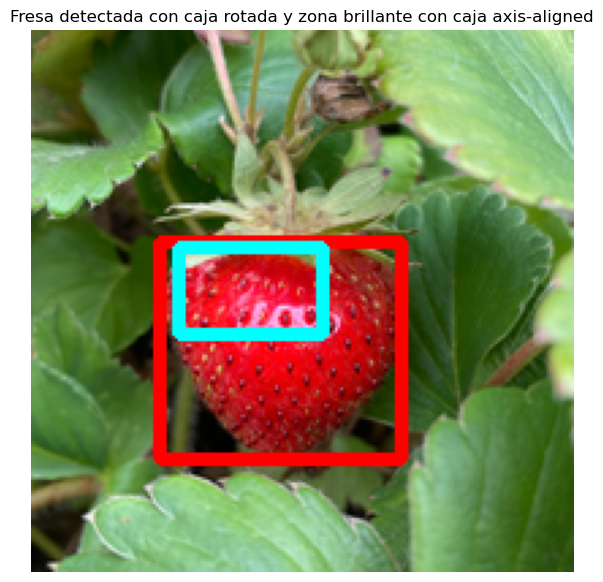

In [238]:
plt.figure(figsize=(7, 8))
plt.imshow(visual)
plt.title("Fresa detectada con caja rotada y zona brillante con caja axis-aligned")
plt.axis("off")
plt.show()

## Qué merece la pena recordar

La idea importante del cuaderno es esta:

- una imagen es un array;
- histogramas y espacios de color sirven para pensar antes de umbralizar;
- HSL y HSV separan mejor brillo, tono y saturación que RGB;
- `scipy.ndimage` resuelve muy bien filtros y morfología;
- `scikit-learn` puede segmentar por clusters cuando no queremos fijar el corte a mano;
- OpenCV sigue siendo excelente para geometría y contornos.

## Retos opcionales

1. Cambiar los umbrales de `hue_hsv`, `saturation_hsv` y `value_hsv` para ver cuándo fallan.
2. Probar `KMeans` con `2`, `3` y `4` clusters dentro de la fresa.
3. Comparar segmentación en RGB frente a segmentación en HSV.
4. Detectar solo las zonas más brillantes de la fresa usando una combinación de saturación y valor.
5. Extraer medidas geométricas simples de la fresa para construir una regla heurística.